In [1]:
import pandas as pd
df = pd.read_excel("/content/sales2.xlsx")
print(df.head())
print(df.info())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invo

In [2]:
import pandas as pd

df = pd.read_excel("/content/sales2.xlsx")

print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [3]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [5]:
df = df.dropna(subset=["Customer ID"])

df = df[~df["Invoice"].astype(str).str.startswith("C")]

df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

df = df.drop_duplicates()

In [6]:
df["TotalAmount"] = df["Quantity"] * df["Price"]
print(df["TotalAmount"].head())

0     83.4
1     81.0
2     81.0
3    100.8
4     30.0
Name: TotalAmount, dtype: float64


In [7]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate",
             lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalAmount", "sum")
)

print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346.0          165         11    372.86
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          3   2671.14
12351.0           11          1    300.93


In [8]:
from sklearn.preprocessing import StandardScaler

features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[features])

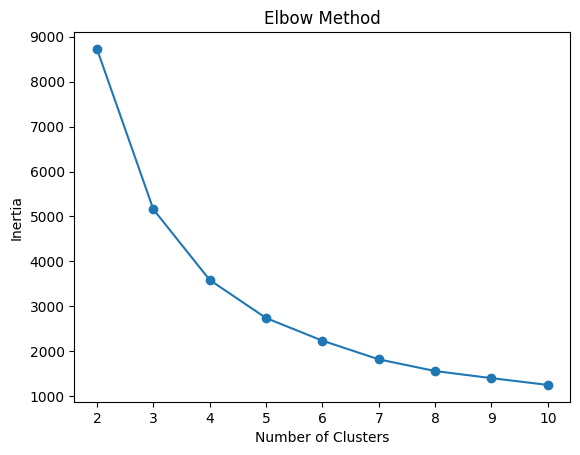

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [11]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Silhouette Score:", silhouette)


Silhouette Score: 0.9314175603189809


In [12]:
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Davies-Bouldin Index:", db_index)

Davies-Bouldin Index: 0.5834201660128137


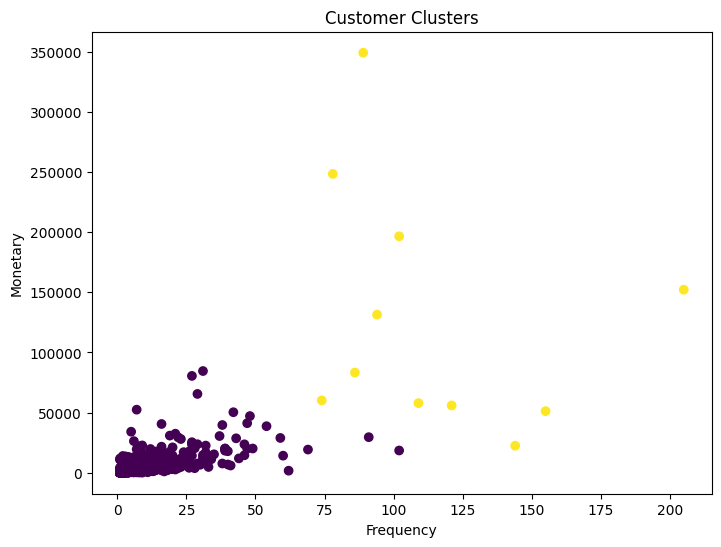

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Clusters")
plt.show()

In [14]:
cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

print(cluster_summary)

           Recency   Frequency       Monetary
Cluster                                      
0        91.392932    4.174843    1718.126437
1         4.727273  114.272727  128051.994545
